In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("P2Deliverable2_raw.csv")
df.sample(5)

,X,Y,OBJECTID,NCESSCH,SURVYEAR,STABR,LEAID,ST_LEAID,LEA_NAME,SCH_NAME,...,TRALM,TRALF,TR,WHALM,WHALF,WH,LATCOD,LONCOD,TOTAL_RACE_CONS,TOTAL_GRADE_CONS
72382,-80.303300,40.660300,74175,420082407319,2022-2023,PA,4200824,PA-127042003,Central Valley SD,Central Valley HS,...,14.0,6.0,20.0,317.0,299.0,616.0,40.660300,-80.303300,True,True
3727,-114.290727,34.141588,3842,40598000495,2022-2023,AZ,405980,AZ-4510,Parker Unified School District (4510),Wallace Elementary School,...,10.0,9.0,19.0,23.0,22.0,45.0,34.141588,-114.290727,True,True
10789,-121.542830,38.911450,11813,62380003595,2022-2023,CA,623800,CA-5171407,Marcum-Illinois Union Elementary,Marcum-Illinois Union Elementary,...,6.0,10.0,16.0,50.0,64.0,114.0,38.911450,-121.542830,True,True
29569,-89.672487,39.800668,31025,173708003818,2022-2023,IL,1737080,IL-51-084-1860-25,Springfield SD 186,Dubois Elem School,...,27.0,31.0,58.0,65.0,66.0,131.0,39.800668,-89.672487,True,True
29960,-87.943623,42.139705,31418,174221004237,2022-2023,IL,1742210,IL-05-016-0210-04,Wheeling CCSD 21,Eugene Field Elem School,...,5.0,3.0,8.0,47.0,34.0,81.0,42.139705,-87.943623,True,True


--- Distribution for LSTATE ---
LSTATE
CA    0.095066
TX    0.092958
NY    0.048759
FL    0.042729
IL    0.042344
Name: proportion, dtype: float64


--- Distribution for SCHOOL_TYPE_TEXT ---
SCHOOL_TYPE_TEXT
Regular School                  0.918322
Alternative Education School    0.050847
Special Education School        0.016206
Career and Technical School     0.014625
Name: proportion, dtype: float64


--- Distribution for SCHOOL_LEVEL ---
SCHOOL_LEVEL
Elementary         0.532675
High               0.236277
Middle             0.165241
Other              0.044442
Prekindergarten    0.015628
Name: proportion, dtype: float64


--- Distribution for GSHI ---
GSHI
05    0.286861
12    0.277142
08    0.225929
06    0.098279
04    0.038695
Name: proportion, dtype: float64


TOTMENROL     4.337203
TOTFENROL     5.115193
TOTFRL        4.831518
REDLCH       15.430600
HI            4.542008
WH            4.374971
TR           16.673270
X             0.234339
Y            -0.260352
dtype: float64


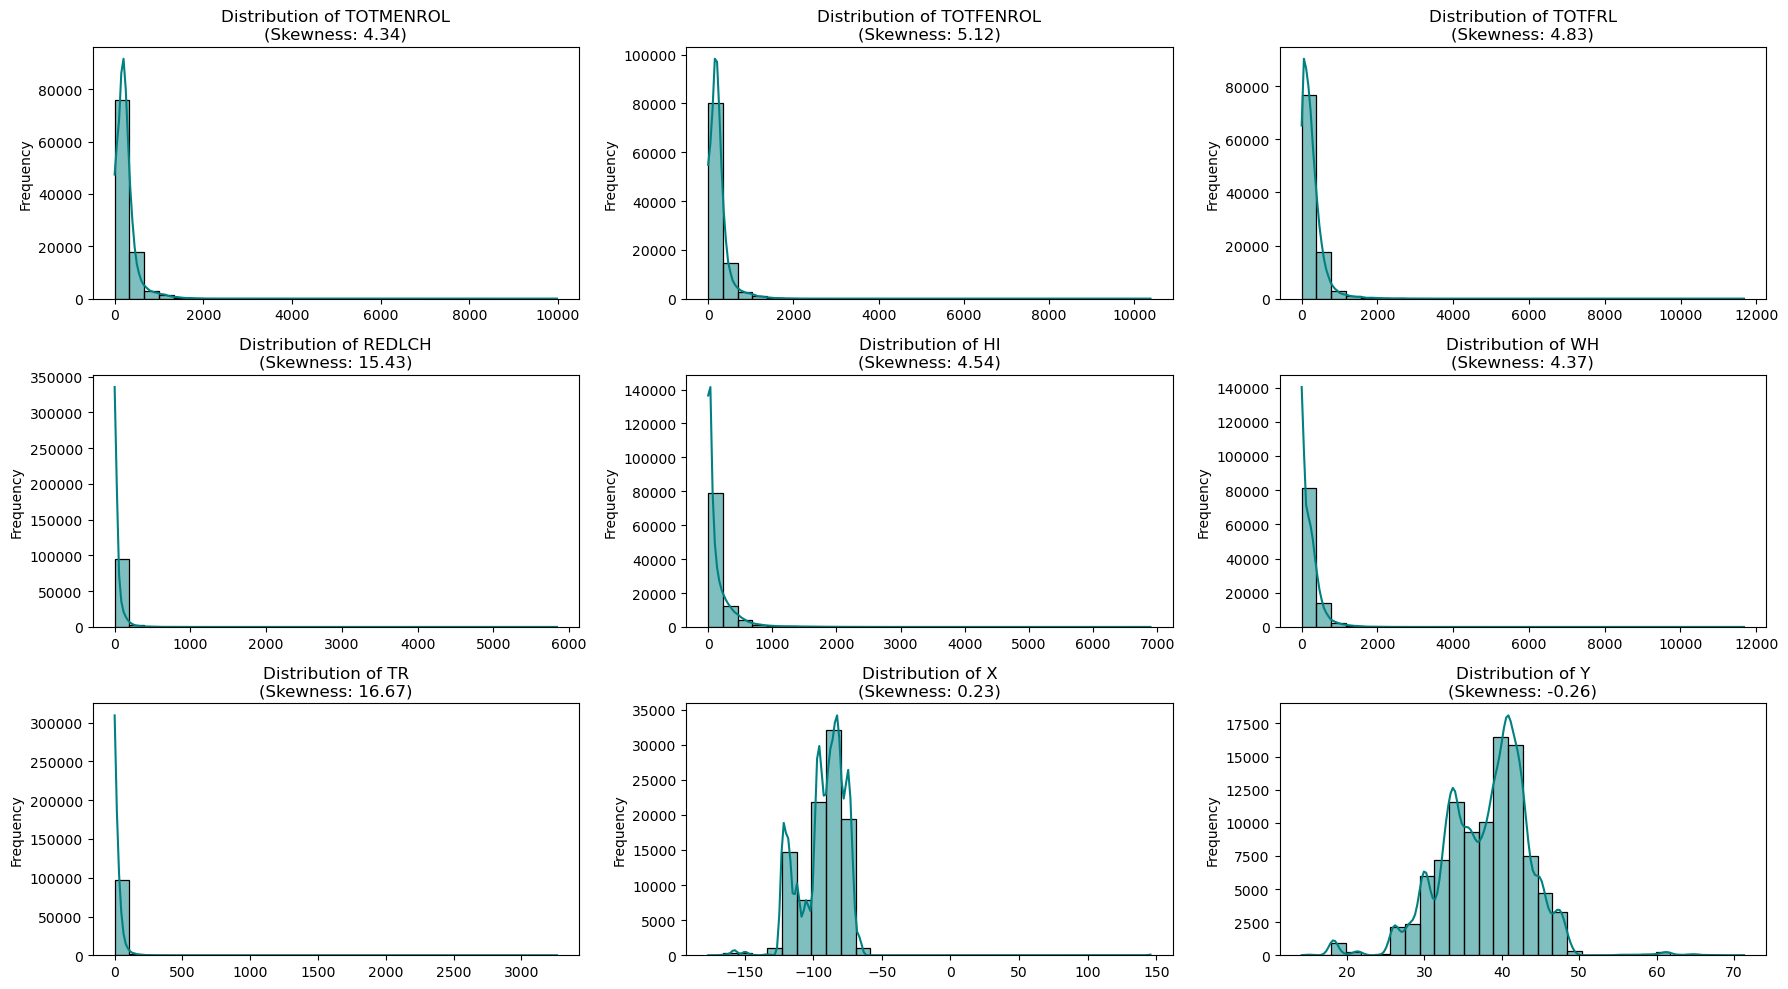

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

cols = ['LSTATE', 'X', 'Y', 'TOTMENROL', 'TOTFENROL', 'TOTFRL', 'HI', 'SCHOOL_TYPE_TEXT', 'WH', 'REDLCH', 'TR', 'SCHOOL_LEVEL', 'GSHI']
cat_cols = ['LSTATE', 'SCHOOL_TYPE_TEXT', 'SCHOOL_LEVEL', 'GSHI']
num_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL','REDLCH','HI', 'WH', 'TR', 'X', 'Y']
le = LabelEncoder()

X = df[cols]
Y = df['STUTERATIO']

for col in cat_cols:
    # We use .astype(str) to avoid errors with NaN values
    X[col] = le.fit_transform(X[col].astype(str))
for col in cat_cols:
    print(f"--- Distribution for {col} ---")
    print(df[col].value_counts(normalize=True).head()) # Shows percentages
    print("\n")
# Calculate skewness for numerical columns

print(df[num_cols].skew())
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2D array to 1D for easy iteration

for i, col in enumerate(num_cols):
    # Plot histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    
    # Add titles that include the skewness value for your report
    skew_val = df[col].skew()
    axes[i].set_title(f'Distribution of {col}\n(Skewness: {skew_val:.2f})', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Task 1. Data Balancing
Choose between the Original Data or Transformed Data.  
N.B. Test only on the original test set, not on the balanced/transformed dataset.

### b. Handling Outliers & Unequal Variance for Regression:

##### Normalization

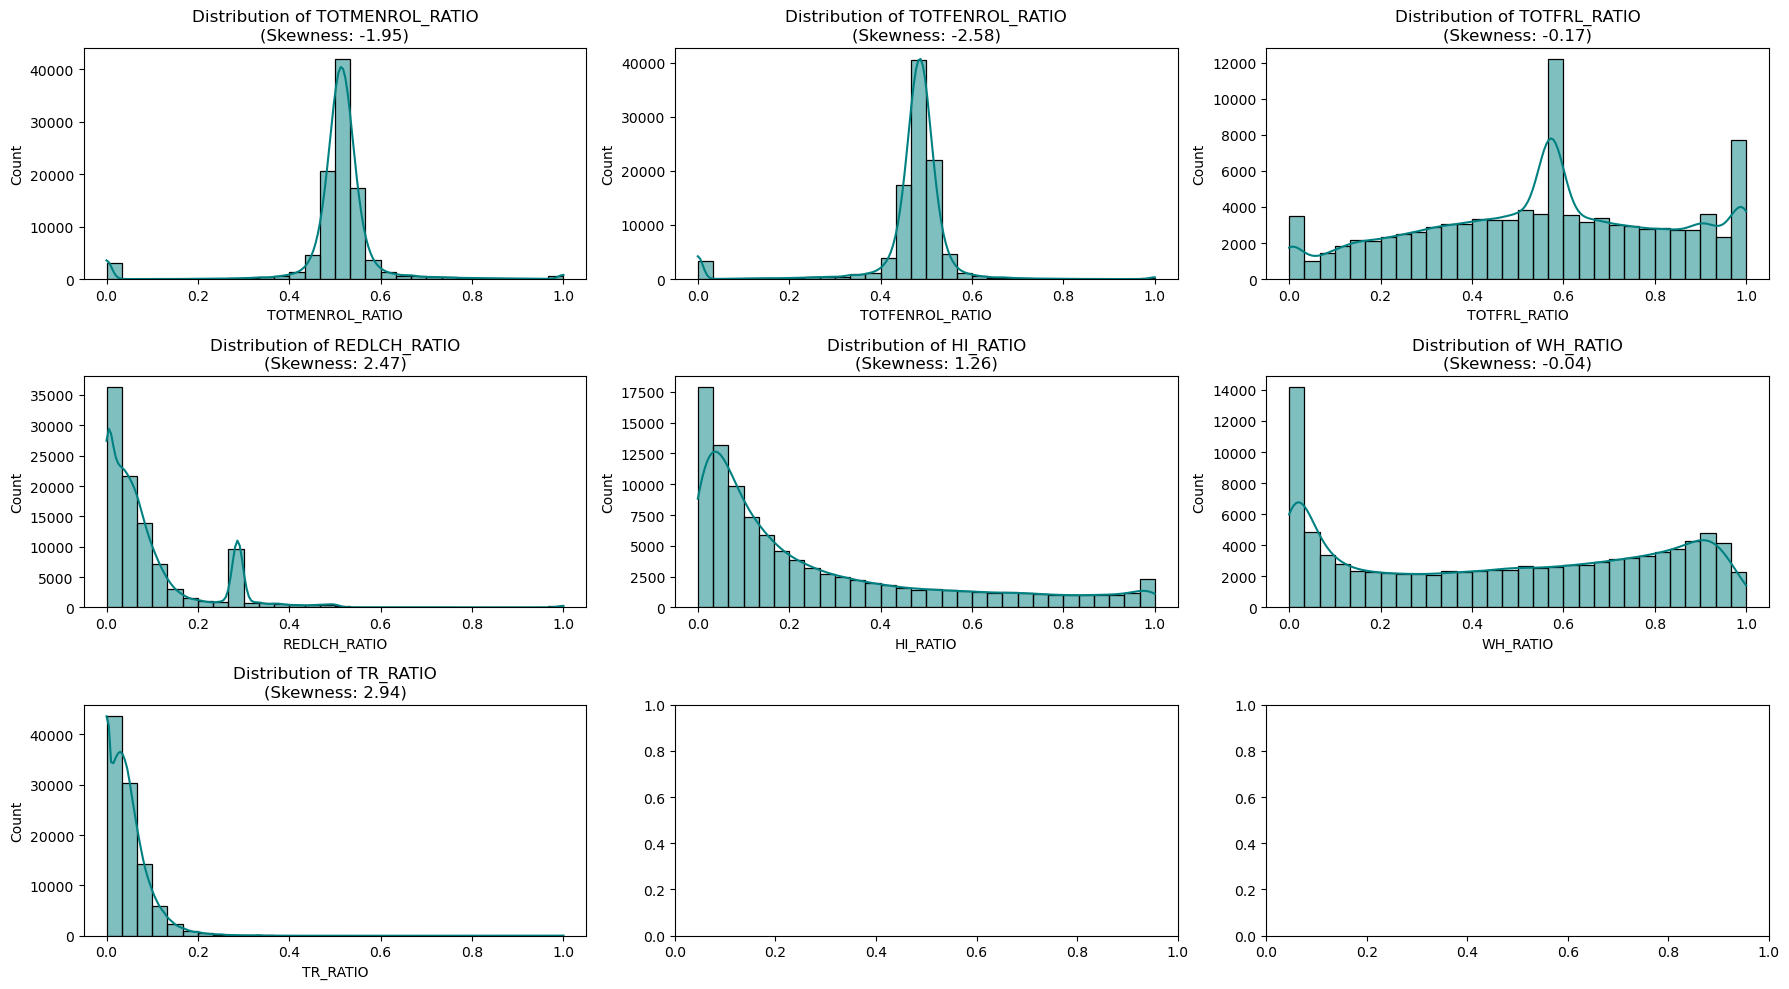

,LSTATE,X,Y,TOTMENROL,TOTFENROL,TOTFRL,HI,SCHOOL_TYPE_TEXT,WH,REDLCH,TR,SCHOOL_LEVEL,GSHI,TOTMENROL_RATIO,TOTFENROL_RATIO,TOTFRL_RATIO,REDLCH_RATIO,HI_RATIO,WH_RATIO,TR_RATIO
69506,37,-96.270571,34.121841,208.0,157.0,246.0,24.0,2,210.0,123.0,38.0,0,7,0.569863,0.430137,0.673973,0.336986,0.065753,0.575342,0.104110
23469,10,-84.320900,33.829400,44.0,26.0,46.0,10.0,2,6.0,2.0,2.0,3,11,0.628571,0.371429,0.657143,0.028571,0.142857,0.085714,0.028571
6923,4,-121.879124,37.338833,43.0,41.0,57.0,69.0,2,2.0,11.0,5.0,2,7,0.511905,0.488095,0.678571,0.130952,0.821429,0.023810,0.059524
36725,18,-92.417923,30.636785,384.0,381.0,496.0,10.0,2,400.0,49.0,41.0,1,11,0.501961,0.498039,0.648366,0.064052,0.013072,0.522876,0.053595
9966,4,-117.968600,33.651800,1137.0,895.0,523.0,358.0,2,1194.0,199.0,203.0,1,11,0.558997,0.440020,0.257129,0.097837,0.176008,0.587021,0.099803


In [10]:
count_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR']

# Create new ratio columns
for col in count_cols:
    # Use .div() to handle division and avoid errors if TOTAL is 0
    X[f'{col}_RATIO'] = X[col] / df['TOTAL']

# Fill any resulting NaNs (from division by zero) with 0
X[[f'{c}_RATIO' for c in count_cols]] = X[[f'{c}_RATIO' for c in count_cols]].fillna(0)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2D array to 1D for easy iteration
for i, col in enumerate(count_cols):
    # Use the new ratio column name here:
    ratio_col = f'{col}_RATIO'
    
    # Plot the RATIO column, not the original raw count
    sns.histplot(X[ratio_col], kde=True, ax=axes[i], color='teal', bins=30)
    
    # Update title and skewness to reflect the ratio data
    skew_val = X[ratio_col].skew()
    axes[i].set_title(f'Distribution of {ratio_col}\n(Skewness: {skew_val:.2f})', fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

X.sample(5)

##### Log Tranformation

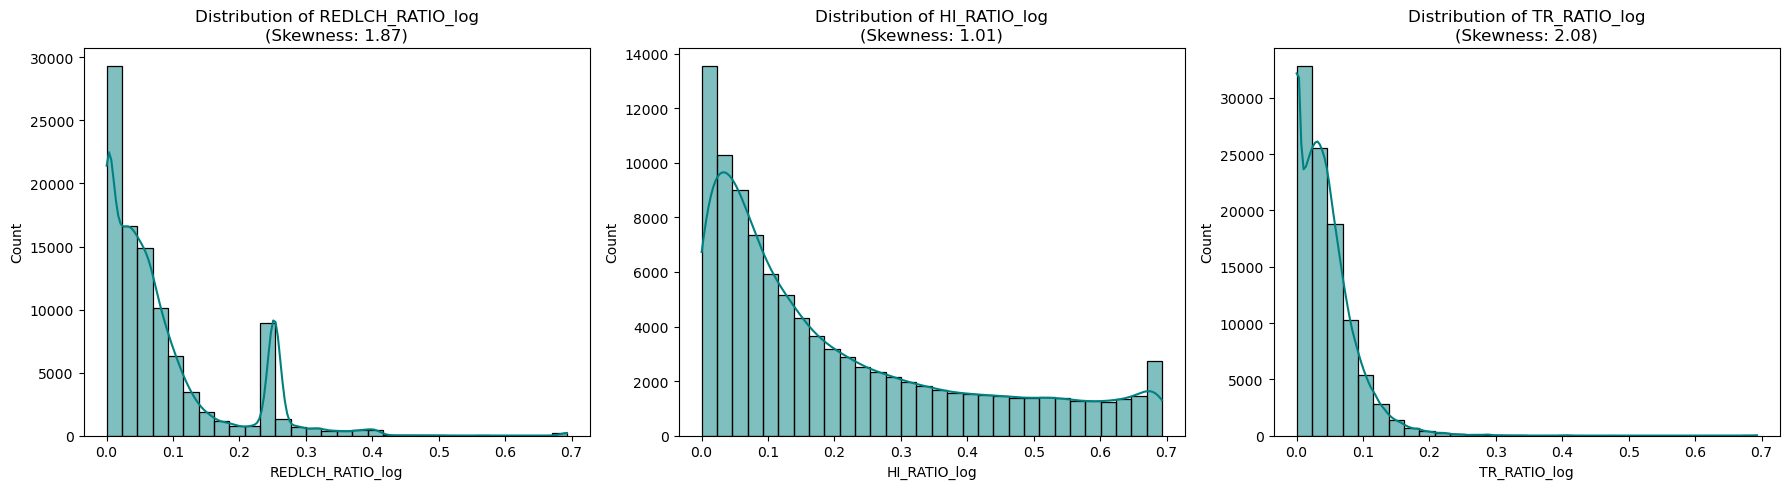

In [15]:
log_cols = ['REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']

X['REDLCH_RATIO_log'] = np.log1p(X['REDLCH_RATIO'])
X['HI_RATIO_log'] = np.log1p(X['HI_RATIO'])
X['TR_RATIO_log'] = np.log1p(X['TR_RATIO'])

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
axes = axes.flatten() # Flatten the 2D array to 1D for easy iteration
for i, col in enumerate(log_cols):
    # Use the new ratio column name here:
    log_col = f'{col}_log'
    
    # Plot the RATIO column, not the original raw count
    sns.histplot(X[log_col], kde=True, ax=axes[i], color='teal', bins=30)
    
    # Update title and skewness to reflect the ratio data
    skew_val = X[log_col].skew()
    axes[i].set_title(f'Distribution of {log_col}\n(Skewness: {skew_val:.2f})', fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

##### BOXCOX

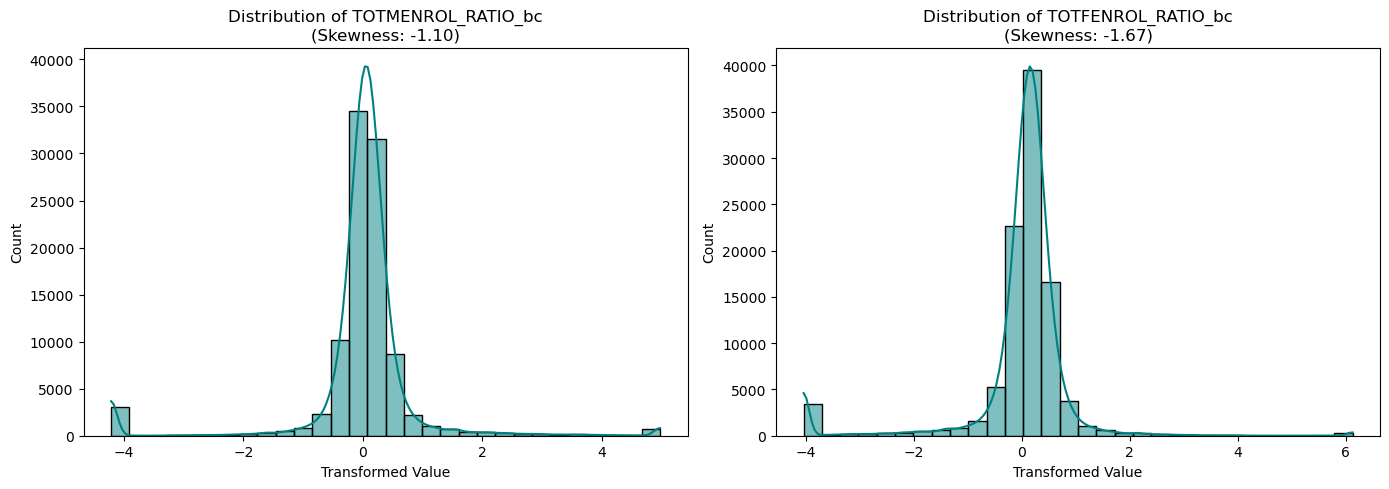

In [19]:
from sklearn.preprocessing import PowerTransformer

# 1. Update the columns list and initialize PowerTransformer
bc_cols = ['TOTMENROL_RATIO', 'TOTFENROL_RATIO']
pt = PowerTransformer(method='box-cox')

for col in bc_cols:
    # IMPORTANT: Box-Cox requires input > 0. 
    # Adding a very small constant (1e-6) to handle any 0.0 ratios.
    X[f'{col}_bc'] = pt.fit_transform(X[[col]] + 1e-6)

# 2. Update the plotting grid (2 columns for 2 features)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
axes = axes.flatten()

for i, col in enumerate(bc_cols):
    bc_col = f'{col}_bc'
    
    # Plot the Box-Cox transformed column
    sns.histplot(X[bc_col], kde=True, ax=axes[i], color='teal', bins=30)
    
    # Calculate new skewness
    skew_val = X[bc_col].skew()
    axes[i].set_title(f'Distribution of {bc_col}\n(Skewness: {skew_val:.2f})', fontsize=12)
    axes[i].set_xlabel('Transformed Value')

plt.tight_layout()
plt.show()

#### Standardizization

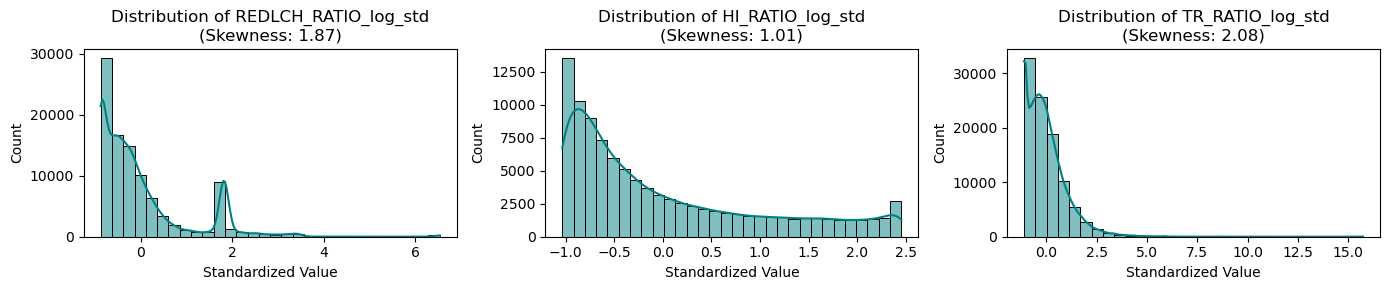

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# List your log-transformed columns
log_cols_to_scale = ['REDLCH_RATIO_log', 'HI_RATIO_log', 'TR_RATIO_log']

# Scale them
X[[f'{c}_std' for c in log_cols_to_scale]] = scaler.fit_transform(X[log_cols_to_scale])

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 3))
axes = axes.flatten()
for i, col in enumerate(log_cols_to_scale):
    std_col = f'{col}_std'
    
    # Plot the Box-Cox transformed column
    sns.histplot(X[std_col], kde=True, ax=axes[i], color='teal', bins=30)
    
    # Calculate new skewness
    skew_val = X[std_col].skew()
    axes[i].set_title(f'Distribution of {std_col}\n(Skewness: {skew_val:.2f})', fontsize=12)
    axes[i].set_xlabel('Standardized Value')

plt.tight_layout()
plt.show()

#### Before vs After Performance and Distribution

                        Model       MAE      RMSE        R2
0              Baseline (Raw)  2.542676  4.511108  0.399596
1  Transformed (Ratio/Log/BC)  2.691475  4.585984  0.379500


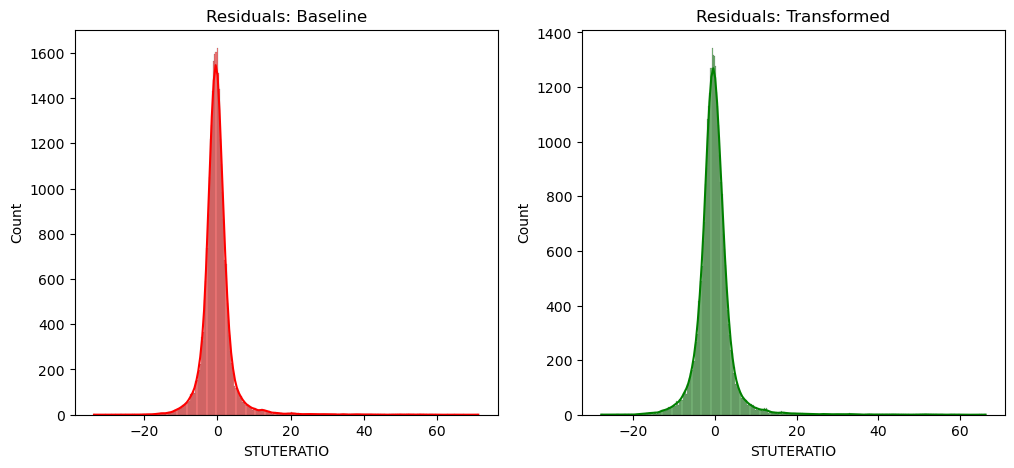

In [25]:
# 1. Baseline Features (Original raw counts)
base_features = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR', 'X', 'Y']

# 2. Transformed Features (Your engineering work)
# Note: Ensure these column names match what you created in previous steps
transformed_features = [
    'TOTMENROL_RATIO_bc', 'TOTFENROL_RATIO_bc', # Box-Cox
    'HI_RATIO_log_std', 'TR_RATIO_log_std', 'REDLCH_RATIO_log_std', # Log
    'WH_RATIO', 'TOTFRL_RATIO', # Normalized
    'X', 'Y']
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

def run_rf_comparison(features, target, label):
    # Split
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)
    
    # Train
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # Predict
    preds = rf.predict(X_test)
    
    # Calculate Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    return {'Model': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Run both
results_before = run_rf_comparison(X[base_features], Y, "Baseline (Raw)")
results_after = run_rf_comparison(X[transformed_features], Y, "Transformed (Ratio/Log/BC)")

# Display results in a table
performance_df = pd.DataFrame([results_before, results_after])
print(performance_df)

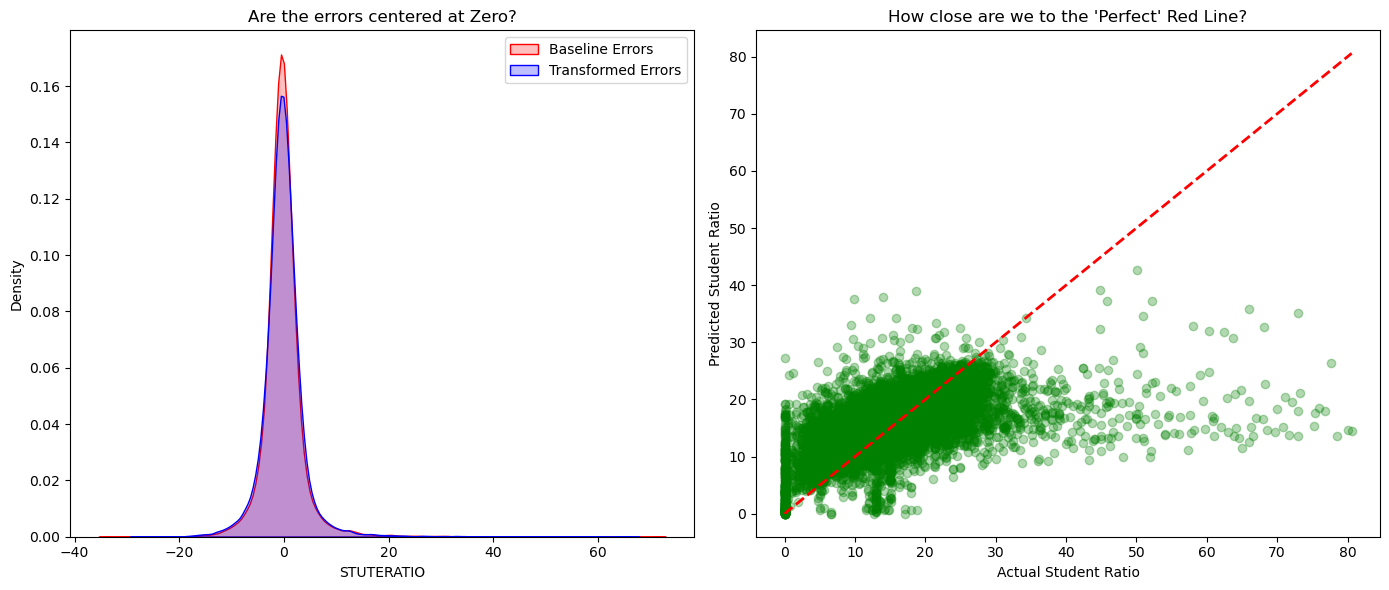

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Errors
error_base = y_te - rf_base.predict(X_te_base)
error_trans = y_te - rf_trans.predict(X_te_trans)

plt.figure(figsize=(14, 6))

# Plot 1: Error Distribution
plt.subplot(1, 2, 1)
sns.kdeplot(error_base, label='Baseline Errors', color='red', fill=True)
sns.kdeplot(error_trans, label='Transformed Errors', color='blue', fill=True)
plt.title("Are the errors centered at Zero?")
plt.legend()

# Plot 2: Prediction vs Actual (The "Ideal Line" Plot)
plt.subplot(1, 2, 2)
plt.scatter(y_te, rf_trans.predict(X_te_trans), alpha=0.3, color='green')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
plt.xlabel("Actual Student Ratio")
plt.ylabel("Predicted Student Ratio")
plt.title("How close are we to the 'Perfect' Red Line?")

plt.tight_layout()
plt.show()

#### Trade-Off

### a. Handling Imbalanced Data for Classification

#### Strategy 1: Random Oversampling

In [28]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Prepare Features (Using your transformed features from Part B)
all_features = cat_cols + transformed_features
X_data = X[all_features]
y_data = Y

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# 3. Address Imbalance using RandomOverSampler (Target-based)
# We create 5 bins (Low to High student ratio) to guide the oversampling process
y_bins = pd.cut(y_train, bins=5, labels=False)

ros = RandomOverSampler(random_state=42)
X_ros, _ = ros.fit_resample(X_train, y_bins)

# Get the actual continuous y-values for the newly duplicated rows
# ros.sample_indices_ allows us to pull the exact target values for the oversampled rows
y_ros = y_train.iloc[ros.sample_indices_]

# 4. Train and Evaluate the ROS Model
rf_ros = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_ros.fit(X_ros, y_ros)
preds_ros = rf_ros.predict(X_test)

# 5. Calculate Metrics
mae_ros = mean_absolute_error(y_test, preds_ros)
rmse_ros = np.sqrt(mean_squared_error(y_test, preds_ros))
r2_ros = r2_score(y_test, preds_ros)

# 6. Display Comparison (Assuming you still have your baseline metrics)
print("--- Part A: Random Over Sampling Results ---")
print(f"MAE:  {mae_ros:.4f}")
print(f"RMSE: {rmse_ros:.4f}")
print(f"R2:   {r2_ros:.4f}")

--- Part A: Random Over Sampling Results ---
MAE:  2.6609
RMSE: 4.7822
R2:   0.3253


#### Strategy 2: SMOTE

In [31]:
from imblearn.over_sampling import SMOTE

# 1. Create Bins for the Target Variable
y_bins = pd.cut(y_train, bins=5, labels=False)

# 2. Check for Singletons
bin_counts = pd.Series(y_bins).value_counts()
rare_bins = bin_counts[bin_counts <= 2].index
mask = ~pd.Series(y_bins).isin(rare_bins).values

X_filtered = X_train[mask]
y_filtered = y_train[mask]
y_bins_filtered = y_bins[mask]

# 3. Apply SMOTE to X and Y simultaneously
# We pass y_filtered as part of the data so SMOTE generates new Y values too
smote = SMOTE(random_state=42, k_neighbors=2)

# We temporarily stack X and y together so SMOTE treats the target as a feature
X_y_combined = np.column_stack((X_filtered, y_filtered))
X_y_resampled, _ = smote.fit_resample(X_y_combined, y_bins_filtered)

# 4. Split them back apart
# X_smote is everything except the last column, y_smote is the last column
X_smote = X_y_resampled[:, :-1]
y_smote = X_y_resampled[:, -1]

# 5. Train and Evaluate
rf_smote = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_smote, y_smote)
preds_smote = rf_smote.predict(X_test)

# 6. Calculate Metrics
mae_smote = mean_absolute_error(y_test, preds_smote)
rmse_smote = np.sqrt(mean_squared_error(y_test, preds_smote))
r2_smote = r2_score(y_test, preds_smote)

# 7. Final Results Printout
print("--- Part A: SMOTE Results ---")
print(f"MAE:  {mae_smote:.4f}")
print(f"RMSE: {rmse_smote:.4f}")
print(f"R2:   {r2_smote:.4f}")

--- Part A: SMOTE Results ---
MAE:  2.6809
RMSE: 4.7822
R2:   0.3253


#### Before vs After Performance

In [32]:
# 1. Run the Baseline (Original) model once
X_train, X_test, y_train, y_test = train_test_split(X[all_features], Y, test_size=0.3, random_state=42)

rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
preds_base = rf_base.predict(X_test)

# Calculate Baseline Metrics
mae_base = mean_absolute_error(y_test, preds_base)
rmse_base = np.sqrt(mean_squared_error(y_test, preds_base))
r2_base = r2_score(y_test, preds_base)

# 2. Print the Final Comparison Table
print(f"{'Strategy':<25} | {'MAE':<8} | {'RMSE':<8} | {'R2':<8}")
print("-" * 60)
print(f"{'Baseline (No Sampling)':<25} | {mae_base:<8.4f} | {rmse_base:<8.4f} | {r2_base:<8.4f}")
print(f"{'Random Over Sampling':<25} | {mae_ros:<8.4f} | {rmse_ros:<8.4f} | {r2_ros:<8.4f}")
print(f"{'SMOTE':<25} | {mae_smote:<8.4f} | {rmse_smote:<8.4f} | {r2_smote:<8.4f}")

Strategy                  | MAE      | RMSE     | R2      
------------------------------------------------------------
Baseline (No Sampling)    | 2.4299   | 4.2907   | 0.4568  
Random Over Sampling      | 2.6609   | 4.7822   | 0.3253  
SMOTE                     | 2.6809   | 4.7822   | 0.3253  


#### Trade-Off

If Baseline is the winner: You can state that "Random Forest's inherent ability to handle imbalanced data through bootstrap aggregating (bagging) meant that artificial sampling (ROS/SMOTE) actually introduced more noise than value."

The RMSE "Tell": If the RMSE is significantly higher in SMOTE/ROS than the Baseline, it’s a sign that the sampling created "outlier" predictions that are very far from the truth, hurting the overall error score.

## Task 2. Hyperparameter Explanation

### Identify key hyperparameters

In [33]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
all_features = cat_cols + base_features
# We will use the 'all_features' set which includes your Part B transformations
X_train, X_test, y_train, y_test = train_test_split(X[all_features], Y, test_size=0.3, random_state=42)

# --- 1. Linear Model (Ridge Regression) ---
# Tuning 'alpha': Higher alpha increases regularization (reduces complexity)
ridge_model = Ridge(alpha=1.0) 
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)

# --- 2. Decision Tree Regressor ---
# Tuning 'max_depth': Limits how many levels the tree grows (prevents overfitting)
# Tuning 'min_samples_split': Higher values prevent the tree from learning tiny noise patterns
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# --- 3. Random Forest Regressor ---
# Tuning 'n_estimators': Number of trees in the forest
# Tuning 'max_features': Limits features per split to increase tree diversity
rf_model = RandomForestRegressor(n_estimators=200, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Helper Function to Print Results ---
def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}\n")

print_metrics("Ridge Regression (alpha=1.0)", y_test, ridge_preds)
print_metrics("Decision Tree (max_depth=5)", y_test, dt_preds)
print_metrics("Random Forest (n_estimators=200)", y_test, rf_preds)

--- Ridge Regression (alpha=1.0) ---
MAE: 3.2557 | RMSE: 5.2369 | R2: 0.1909

--- Decision Tree (max_depth=5) ---
MAE: 2.9558 | RMSE: 4.8128 | R2: 0.3166

--- Random Forest (n_estimators=200) ---
MAE: 2.2848 | RMSE: 4.1238 | R2: 0.4983



## Task 3. Hyperparameter Tuning (Grid Search)
• At least 5–10 parameter combinations for Grid Search  
• Cross-validation = minimum 5-fold

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Define Parameter Grids (Targeting 5-10 combinations each)
ridge_params = {
    'alpha': [0.1, 1.0, 10.0, 100.0, 500.0] # 5 combinations
}

dt_params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 10, 20] # 4x3 = 12 combinations
}

rf_params = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20] # 2x3x2 = 12 combinations
}

# 2. Initialize Models
models = [
    ('Ridge', Ridge(), ridge_params),
    ('Decision Tree', DecisionTreeRegressor(random_state=42), dt_params),
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1), rf_params)
]

# 3. Run GridSearch
tuned_results = []

for name, model, params in models:
    print(f"Tuning {name}...")
    grid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train) # Use the raw X_train/y_train that performed best
    
    # Get best model and predict
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    tuned_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

# 4. Display Results
tuned_df = pd.DataFrame(tuned_results)
print("\n--- Final Tuned Results ---")
print(tuned_df[['Model', 'MAE', 'RMSE', 'R2']])
print("\nDetailed Best Parameters:")
for res in tuned_results:
    print(f"{res['Model']}: {res['Best Params']}")

Tuning Ridge...
Tuning Decision Tree...
Tuning Random Forest...

--- Final Tuned Results ---
           Model       MAE      RMSE        R2
0          Ridge  3.255633  5.236847  0.190873
1  Decision Tree  2.661176  4.652415  0.361393
2  Random Forest  2.311032  4.135053  0.495526

Detailed Best Parameters:
Ridge: {'alpha': 500.0}
Decision Tree: {'max_depth': 10, 'min_samples_split': 20}
Random Forest: {'max_depth': 20, 'max_features': 'log2', 'n_estimators': 200}


## Task 4. Model Evaluation & Best Model Selection